<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/Notebooks/12_SEAID_Advanced_Analysis_and_Extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEAID Advanced Analysis and Extensions

## Purpose

This notebook extends the completed SEAID pipeline without duplicating the explainability and calibration analyses now completed in Notebook 11.

Notebook 11 already provides:

- global SHAP explanations,
- behavioral and academic SHAP importance,
- a local waterfall explanation for a high-risk student,
- probability calibration,
- Brier score evaluation,
- deployment workflow guidance, and
- ethical-use principles.

Notebook 12 therefore focuses on the remaining advanced extensions:

1. Fairness and subgroup performance analysis
2. Decision Confidence Index development
3. Prediction-confidence and uncertainty review
4. Data-quality and drift-monitoring baselines
5. Operational model-monitoring thresholds
6. Deployment-readiness assessment

The operational analyses continue to use the saved Day-30 XGBoost model selected in the SEAID workflow.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

PROCESSED_DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)

MODEL_DIR = (
    PROJECT_DIR /
    "models"
)

RESULTS_DIR = (
    PROJECT_DIR /
    "results"
)

FIGURE_DIR = (
    PROJECT_DIR /
    "figures"
)

OUTPUTS_DIR = (
    PROJECT_DIR /
    "outputs"
)

for directory in [
    RESULTS_DIR,
    FIGURE_DIR,
    OUTPUTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

DAY30_DATA_PATH = (
    PROCESSED_DATA_DIR /
    "early_warning_day30_dataset.csv"
)

DAY30_MODEL_PATH = (
    MODEL_DIR /
    "xgboost_day30.joblib"
)

NOTEBOOK11_SUMMARY_PATH = (
    RESULTS_DIR /
    "day30_model_summary.csv"
)

NOTEBOOK11_SHAP_PATH = (
    RESULTS_DIR /
    "shap_feature_importance_day30.csv"
)

print("Dataset:", DAY30_DATA_PATH)
print("Model:", DAY30_MODEL_PATH)
print(
    "Notebook 11 model summary:",
    NOTEBOOK11_SUMMARY_PATH
)

Dataset: /content/drive/MyDrive/SEAID_Framework/data/processed/early_warning_day30_dataset.csv
Model: /content/drive/MyDrive/SEAID_Framework/models/xgboost_day30.joblib
Notebook 11 model summary: /content/drive/MyDrive/SEAID_Framework/results/day30_model_summary.csv


## Load the Day-30 Operational Model and Dataset

In [3]:
if not DAY30_DATA_PATH.exists():
    raise FileNotFoundError(
        "Day-30 dataset not found. "
        "Run Notebook 02 first."
    )

if not DAY30_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Day-30 XGBoost model not found. "
        "Run Notebook 07 first."
    )

day30_df = pd.read_csv(
    DAY30_DATA_PATH
)

xgb_day30 = joblib.load(
    DAY30_MODEL_PATH
)

print(
    "Dataset shape:",
    day30_df.shape
)

print(
    "Model type:",
    type(xgb_day30)
)

Dataset shape: (32593, 82)
Model type: <class 'sklearn.pipeline.Pipeline'>


In [4]:
TARGET = "target_success"

if TARGET not in day30_df.columns:
    raise KeyError(
        f"Expected target column '{TARGET}' "
        "was not found."
    )

y = day30_df[TARGET].astype(int)

if hasattr(
    xgb_day30,
    "feature_names_in_"
):
    expected_features = list(
        xgb_day30.feature_names_in_
    )

    X = day30_df.reindex(
        columns=expected_features
    )

else:
    columns_to_drop = [
        TARGET,
        "final_result",
        "id_student"
    ]

    X = day30_df.drop(
        columns=[
            column
            for column in columns_to_drop
            if column in day30_df.columns
        ]
    )

print("Predictor shape:", X.shape)
print("Outcome distribution:")
display(y.value_counts())

Predictor shape: (32593, 74)
Outcome distribution:


,count
target_success,
0,17208
1,15385


In [5]:
success_probability = (
    xgb_day30.predict_proba(X)[:, 1]
)

risk_probability = (
    1 - success_probability
)

predicted_success = (
    success_probability >= 0.50
).astype(int)

predicted_risk = (
    risk_probability >= 0.50
).astype(int)

## Confirm Notebook 11 Outputs

Notebook 12 does not recreate SHAP or calibration analyses. Instead, it verifies whether Notebook 11 produced its expected outputs and uses the saved model-summary information when available.

In [6]:
notebook11_expected_outputs = [
    RESULTS_DIR /
    "shap_feature_importance_day30.csv",
    RESULTS_DIR /
    "shap_behavioral_academic_importance_day30.csv",
    RESULTS_DIR /
    "day30_model_summary.csv",
    FIGURE_DIR /
    "shap_summary_day30.png",
    FIGURE_DIR /
    "shap_global_importance_day30.png",
    FIGURE_DIR /
    "highest_risk_student_waterfall.png",
    FIGURE_DIR /
    "day30_calibration_curve.png"
]

notebook11_verification = pd.DataFrame(
    {
        "Notebook 11 Output": [
            output_path.name
            for output_path
            in notebook11_expected_outputs
        ],
        "Exists": [
            output_path.exists()
            for output_path
            in notebook11_expected_outputs
        ]
    }
)

display(notebook11_verification)

,Notebook 11 Output,Exists
0,shap_feature_importance_day30.csv,True
1,shap_behavioral_academic_importance_day30.csv,True
2,day30_model_summary.csv,True
3,shap_summary_day30.png,True
4,shap_global_importance_day30.png,True
5,highest_risk_student_waterfall.png,True
6,day30_calibration_curve.png,True


In [7]:
if NOTEBOOK11_SUMMARY_PATH.exists():

    notebook11_model_summary = pd.read_csv(
        NOTEBOOK11_SUMMARY_PATH
    )

    display(
        notebook11_model_summary
    )

else:
    notebook11_model_summary = pd.DataFrame()

    print(
        "Notebook 11 model summary was not found. "
        "Notebook 12 will calculate the required "
        "probability metrics directly."
    )

,Metric,Value
0,Accuracy,0.805326
1,ROC-AUC,0.892015
2,Brier Score,0.134333


# 1. Fairness and Subgroup Performance Analysis

This section evaluates whether predictive performance differs across available demographic and educational groups.

The analysis reports:

- group size,
- accuracy,
- successful-student recall,
- unsuccessful-student recall,
- false-positive rate,
- false-negative rate,
- ROC-AUC, and
- mean predicted risk.

These are descriptive diagnostics. Differences require contextual review and do not independently prove fairness or unfairness.

In [8]:
candidate_group_columns = [
    "gender",
    "age_band",
    "disability",
    "highest_education",
    "imd_band",
    "region"
]

available_group_columns = [
    column
    for column in candidate_group_columns
    if column in day30_df.columns
]

print(
    "Available fairness columns:",
    available_group_columns
)

Available fairness columns: ['gender', 'disability']


In [9]:
def calculate_group_metrics(
    data,
    group_column,
    y_true,
    probabilities,
    threshold=0.50,
    minimum_group_size=30
):
    rows = []

    working_df = pd.DataFrame(
        {
            "Group": (
                data[group_column]
                .fillna("Missing")
                .astype(str)
            ),
            "Actual Success": np.asarray(
                y_true
            ),
            "Success Probability": np.asarray(
                probabilities
            )
        }
    )

    working_df["Predicted Success"] = (
        working_df[
            "Success Probability"
        ] >= threshold
    ).astype(int)

    for group_value, group_df in working_df.groupby(
        "Group"
    ):

        if len(group_df) < minimum_group_size:
            continue

        tn, fp, fn, tp = confusion_matrix(
            group_df["Actual Success"],
            group_df["Predicted Success"],
            labels=[0, 1]
        ).ravel()

        group_auc = np.nan

        if (
            group_df[
                "Actual Success"
            ].nunique() == 2
        ):
            group_auc = roc_auc_score(
                group_df[
                    "Actual Success"
                ],
                group_df[
                    "Success Probability"
                ]
            )

        rows.append(
            {
                "Group Column": group_column,
                "Group": group_value,
                "Students": len(group_df),
                "Accuracy": accuracy_score(
                    group_df[
                        "Actual Success"
                    ],
                    group_df[
                        "Predicted Success"
                    ]
                ),
                "Precision Successful": precision_score(
                    group_df[
                        "Actual Success"
                    ],
                    group_df[
                        "Predicted Success"
                    ],
                    zero_division=0
                ),
                "Recall Successful": recall_score(
                    group_df[
                        "Actual Success"
                    ],
                    group_df[
                        "Predicted Success"
                    ],
                    zero_division=0
                ),
                "Recall Unsuccessful": (
                    tn / (tn + fp)
                    if (tn + fp) > 0
                    else np.nan
                ),
                "False Positive Rate": (
                    fp / (fp + tn)
                    if (fp + tn) > 0
                    else np.nan
                ),
                "False Negative Rate": (
                    fn / (fn + tp)
                    if (fn + tp) > 0
                    else np.nan
                ),
                "ROC-AUC": group_auc,
                "Mean Predicted Risk": (
                    1
                    - group_df[
                        "Success Probability"
                    ].mean()
                )
            }
        )

    return pd.DataFrame(rows)

In [10]:
fairness_frames = []

for group_column in available_group_columns:

    group_metrics = calculate_group_metrics(
        data=day30_df,
        group_column=group_column,
        y_true=y,
        probabilities=success_probability,
        threshold=0.50
    )

    if not group_metrics.empty:
        fairness_frames.append(
            group_metrics
        )

if fairness_frames:

    fairness_results_df = pd.concat(
        fairness_frames,
        ignore_index=True
    )

    fairness_results_df = (
        fairness_results_df
        .sort_values(
            [
                "Group Column",
                "Group"
            ]
        )
        .reset_index(drop=True)
    )

    display(fairness_results_df)

else:
    fairness_results_df = pd.DataFrame()

    print(
        "No eligible subgroup variables "
        "were available."
    )

,Group Column,Group,Students,Accuracy,Precision Successful,Recall Successful,Recall Unsuccessful,False Positive Rate,False Negative Rate,ROC-AUC,Mean Predicted Risk
0,disability,0,29429,0.803969,0.763061,0.860206,0.751688,0.248312,0.139794,0.890454,0.518393
1,disability,1,3164,0.817952,0.751394,0.781276,0.840572,0.159428,0.218724,0.902557,0.614672
2,gender,0,17875,0.812420,0.772177,0.842418,0.786672,0.213328,0.157582,0.899197,0.537238
3,gender,1,14718,0.796712,0.751306,0.867443,0.730267,0.269733,0.132557,0.882523,0.516203


In [11]:
if not fairness_results_df.empty:

    fairness_gap_summary = (
        fairness_results_df
        .groupby(
            "Group Column",
            as_index=False
        )
        .agg(
            Minimum_ROC_AUC=(
                "ROC-AUC",
                "min"
            ),
            Maximum_ROC_AUC=(
                "ROC-AUC",
                "max"
            ),
            Minimum_Recall_Unsuccessful=(
                "Recall Unsuccessful",
                "min"
            ),
            Maximum_Recall_Unsuccessful=(
                "Recall Unsuccessful",
                "max"
            ),
            Minimum_Accuracy=(
                "Accuracy",
                "min"
            ),
            Maximum_Accuracy=(
                "Accuracy",
                "max"
            )
        )
    )

    fairness_gap_summary[
        "ROC-AUC Gap"
    ] = (
        fairness_gap_summary[
            "Maximum_ROC_AUC"
        ]
        - fairness_gap_summary[
            "Minimum_ROC_AUC"
        ]
    )

    fairness_gap_summary[
        "Recall Unsuccessful Gap"
    ] = (
        fairness_gap_summary[
            "Maximum_Recall_Unsuccessful"
        ]
        - fairness_gap_summary[
            "Minimum_Recall_Unsuccessful"
        ]
    )

    fairness_gap_summary[
        "Accuracy Gap"
    ] = (
        fairness_gap_summary[
            "Maximum_Accuracy"
        ]
        - fairness_gap_summary[
            "Minimum_Accuracy"
        ]
    )

    display(fairness_gap_summary)

,Group Column,Minimum_ROC_AUC,Maximum_ROC_AUC,Minimum_Recall_Unsuccessful,Maximum_Recall_Unsuccessful,Minimum_Accuracy,Maximum_Accuracy,ROC-AUC Gap,Recall Unsuccessful Gap,Accuracy Gap
0,disability,0.890454,0.902557,0.751688,0.840572,0.803969,0.817952,0.012104,0.088884,0.013983
1,gender,0.882523,0.899197,0.730267,0.786672,0.796712,0.812420,0.016675,0.056405,0.015708


In [12]:
if not fairness_results_df.empty:

    FAIRNESS_RESULTS_PATH = (
        RESULTS_DIR /
        "day30_fairness_metrics.csv"
    )

    FAIRNESS_GAPS_PATH = (
        RESULTS_DIR /
        "day30_fairness_gap_summary.csv"
    )

    fairness_results_df.to_csv(
        FAIRNESS_RESULTS_PATH,
        index=False
    )

    fairness_gap_summary.to_csv(
        FAIRNESS_GAPS_PATH,
        index=False
    )

    print("Saved:", FAIRNESS_RESULTS_PATH)
    print("Saved:", FAIRNESS_GAPS_PATH)

Saved: /content/drive/MyDrive/SEAID_Framework/results/day30_fairness_metrics.csv
Saved: /content/drive/MyDrive/SEAID_Framework/results/day30_fairness_gap_summary.csv


## Fairness Visualization

The chart below compares recall for unsuccessful students across eligible groups. Lower recall means a larger proportion of unsuccessful students are not identified by the model.

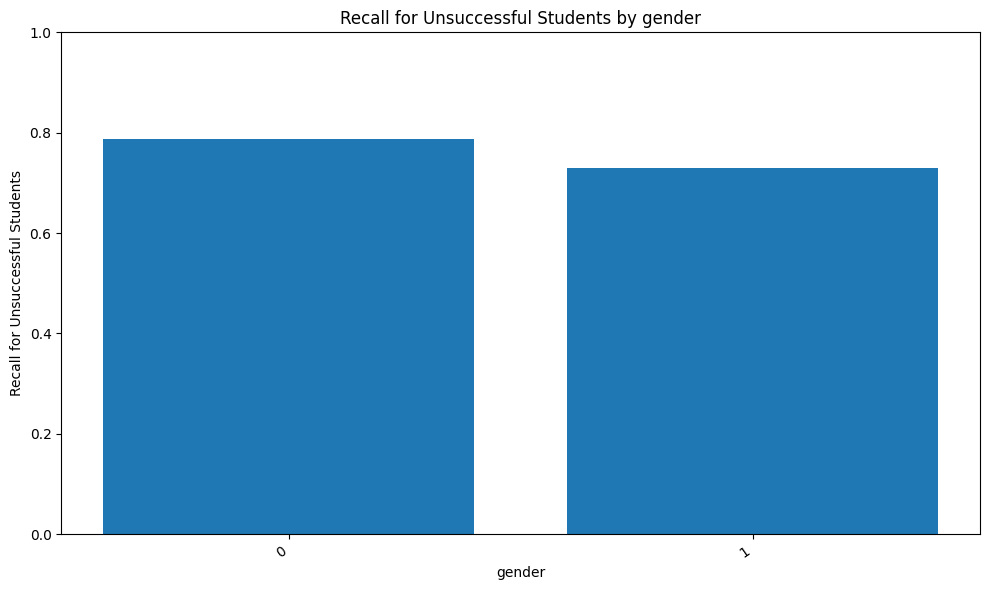

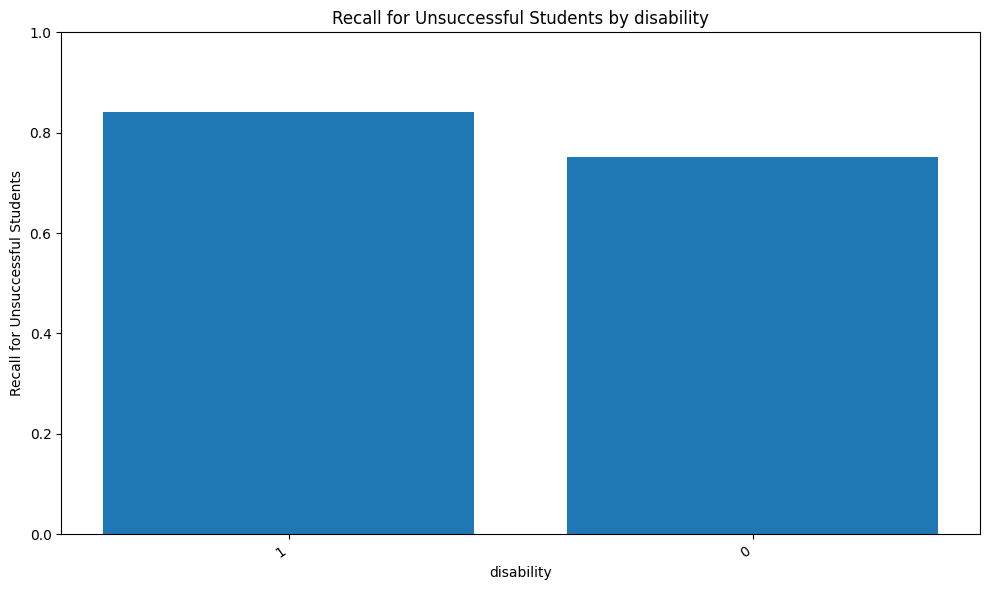

In [13]:
if not fairness_results_df.empty:

    for group_column in available_group_columns:

        plot_data = (
            fairness_results_df[
                fairness_results_df[
                    "Group Column"
                ] == group_column
            ]
            .sort_values(
                "Recall Unsuccessful",
                ascending=False
            )
        )

        if plot_data.empty:
            continue

        plt.figure(
            figsize=(10, 6)
        )

        plt.bar(
            plot_data["Group"],
            plot_data[
                "Recall Unsuccessful"
            ]
        )

        plt.title(
            "Recall for Unsuccessful Students "
            f"by {group_column}"
        )

        plt.xlabel(group_column)
        plt.ylabel(
            "Recall for Unsuccessful Students"
        )
        plt.ylim(0, 1)
        plt.xticks(
            rotation=35,
            ha="right"
        )
        plt.tight_layout()

        output_path = (
            FIGURE_DIR /
            f"fairness_recall_unsuccessful_"
            f"{group_column}.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

# 2. Decision Confidence Index

The Decision Confidence Index (DCI) communicates how far a prediction lies from the decision boundary while accounting for overall probability quality.

The score is not a replacement for predicted probability. It is a communication aid for advisors.

This implementation combines:

- distance from the 0.50 threshold,
- the model's Brier score, and
- agreement between the predicted class and observed outcome for retrospective validation.

In [14]:
brier_score = brier_score_loss(
    y,
    success_probability
)

boundary_confidence = (
    np.abs(
        success_probability - 0.50
    ) * 2
)

calibration_factor = max(
    0.0,
    1.0 - brier_score
)

decision_confidence_index = (
    100
    * boundary_confidence
    * calibration_factor
)

decision_confidence_index = np.clip(
    decision_confidence_index,
    0,
    100
)

print(
    f"Brier score used in DCI: "
    f"{brier_score:.4f}"
)

Brier score used in DCI: 0.1343


In [15]:
def assign_confidence_band(score):

    if score >= 75:
        return "High Confidence"

    if score >= 50:
        return "Moderate Confidence"

    if score >= 25:
        return "Low Confidence"

    return "Very Low Confidence"

In [16]:
confidence_results_df = pd.DataFrame(
    {
        "id_student": (
            day30_df["id_student"]
            if "id_student" in day30_df.columns
            else np.arange(
                len(day30_df)
            )
        ),
        "Actual Success": y.to_numpy(),
        "Predicted Success": predicted_success,
        "Success Probability": success_probability,
        "Risk Probability": risk_probability,
        "Decision Confidence Index": (
            decision_confidence_index
        )
    }
)

confidence_results_df[
    "Confidence Band"
] = (
    confidence_results_df[
        "Decision Confidence Index"
    ]
    .apply(assign_confidence_band)
)

confidence_results_df[
    "Prediction Correct"
] = (
    confidence_results_df[
        "Actual Success"
    ]
    == confidence_results_df[
        "Predicted Success"
    ]
)

display(
    confidence_results_df.head()
)

,id_student,Actual Success,Predicted Success,Success Probability,Risk Probability,Decision Confidence Index,Confidence Band,Prediction Correct
0,11391,1,1,0.758025,0.241975,44.672685,Low Confidence,True
1,28400,1,1,0.777615,0.222385,48.064454,Low Confidence,True
2,30268,0,0,0.047262,0.952738,78.384097,High Confidence,True
3,31604,1,1,0.917988,0.082012,72.367785,Moderate Confidence,True
4,32885,1,1,0.702647,0.297353,35.085010,Low Confidence,True


In [17]:
confidence_band_summary = (
    confidence_results_df
    .groupby(
        "Confidence Band",
        as_index=False
    )
    .agg(
        Students=(
            "id_student",
            "count"
        ),
        Mean_Confidence=(
            "Decision Confidence Index",
            "mean"
        ),
        Mean_Risk=(
            "Risk Probability",
            "mean"
        ),
        Retrospective_Accuracy=(
            "Prediction Correct",
            "mean"
        )
    )
)

confidence_order = [
    "Very Low Confidence",
    "Low Confidence",
    "Moderate Confidence",
    "High Confidence"
]

confidence_band_summary[
    "Confidence Band"
] = pd.Categorical(
    confidence_band_summary[
        "Confidence Band"
    ],
    categories=confidence_order,
    ordered=True
)

confidence_band_summary = (
    confidence_band_summary
    .sort_values(
        "Confidence Band"
    )
)

display(
    confidence_band_summary
)

,Confidence Band,Students,Mean_Confidence,Mean_Risk,Retrospective_Accuracy
3,Very Low Confidence,8303,12.597464,0.486928,0.592316
1,Low Confidence,9355,37.699220,0.412979,0.762052
2,Moderate Confidence,8144,61.815429,0.376823,0.916871
0,High Confidence,6791,83.429786,0.916709,0.991607


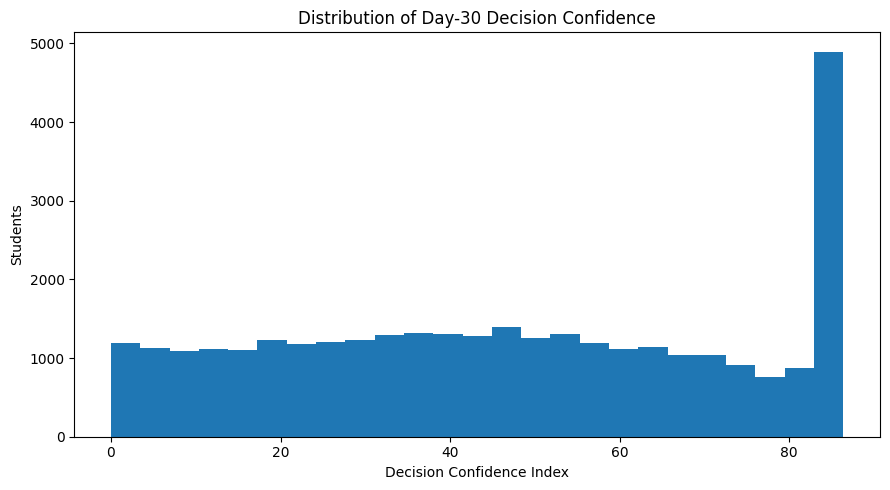

In [18]:
CONFIDENCE_RESULTS_PATH = (
    RESULTS_DIR /
    "day30_decision_confidence_index.csv"
)

CONFIDENCE_SUMMARY_PATH = (
    RESULTS_DIR /
    "day30_decision_confidence_summary.csv"
)

confidence_results_df.to_csv(
    CONFIDENCE_RESULTS_PATH,
    index=False
)

confidence_band_summary.to_csv(
    CONFIDENCE_SUMMARY_PATH,
    index=False
)

plt.figure(figsize=(9, 5))

plt.hist(
    confidence_results_df[
        "Decision Confidence Index"
    ],
    bins=25
)

plt.xlabel(
    "Decision Confidence Index"
)
plt.ylabel("Students")
plt.title(
    "Distribution of Day-30 "
    "Decision Confidence"
)
plt.tight_layout()

DCI_FIGURE_PATH = (
    FIGURE_DIR /
    "day30_decision_confidence_distribution.png"
)

plt.savefig(
    DCI_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 3. Confidence and Prediction-Error Review

A useful confidence score should separate more reliable predictions from ambiguous predictions. This retrospective analysis evaluates accuracy by confidence band.

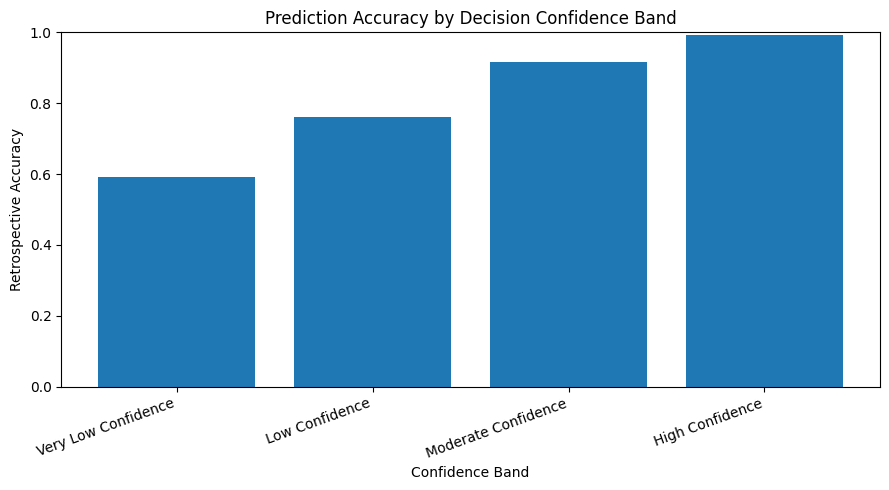

In [19]:
plt.figure(figsize=(9, 5))

plt.bar(
    confidence_band_summary[
        "Confidence Band"
    ].astype(str),
    confidence_band_summary[
        "Retrospective_Accuracy"
    ]
)

plt.xlabel("Confidence Band")
plt.ylabel("Retrospective Accuracy")
plt.title(
    "Prediction Accuracy by "
    "Decision Confidence Band"
)
plt.ylim(0, 1)
plt.xticks(
    rotation=20,
    ha="right"
)
plt.tight_layout()

CONFIDENCE_ACCURACY_PATH = (
    FIGURE_DIR /
    "day30_accuracy_by_confidence_band.png"
)

plt.savefig(
    CONFIDENCE_ACCURACY_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
low_confidence_cases = (
    confidence_results_df[
        confidence_results_df[
            "Confidence Band"
        ].isin(
            [
                "Very Low Confidence",
                "Low Confidence"
            ]
        )
    ]
    .sort_values(
        "Decision Confidence Index"
    )
)

display(
    low_confidence_cases.head(20)
)

LOW_CONFIDENCE_PATH = (
    RESULTS_DIR /
    "day30_low_confidence_cases.csv"
)

low_confidence_cases.to_csv(
    LOW_CONFIDENCE_PATH,
    index=False
)

,id_student,Actual Success,Predicted Success,Success Probability,Risk Probability,Decision Confidence Index,Confidence Band,Prediction Correct
22732,446440,1,1,0.500026,0.499974,0.004551,Very Low Confidence,True
14675,350949,0,0,0.499972,0.500028,0.004768,Very Low Confidence,True
26925,613013,0,1,0.500035,0.499965,0.006109,Very Low Confidence,False
14705,370367,0,1,0.500057,0.499943,0.009938,Very Low Confidence,False
23034,526896,1,1,0.500068,0.499932,0.011744,Very Low Confidence,True
30757,601122,0,0,0.499889,0.500111,0.019261,Very Low Confidence,True
1877,546500,0,1,0.500112,0.499888,0.019349,Very Low Confidence,False
26331,319042,1,1,0.500143,0.499857,0.024695,Very Low Confidence,True
20753,612127,1,1,0.500147,0.499853,0.025469,Very Low Confidence,True
14318,2502707,0,0,0.499847,0.500153,0.026511,Very Low Confidence,True


# 4. Data-Quality and Drift-Monitoring Baseline

This section creates reference statistics for future cohorts.

The baseline can later be compared with incoming data to identify:

- changes in feature distributions,
- increased missingness,
- changes in predicted-risk distributions,
- changes in class balance, and
- deterioration in model performance.

In [21]:
numeric_features = (
    X.select_dtypes(
        include=[
            "number",
            "bool"
        ]
    )
    .columns
    .tolist()
)

drift_baseline_rows = []

for feature in numeric_features:

    feature_series = pd.to_numeric(
        X[feature],
        errors="coerce"
    )

    drift_baseline_rows.append(
        {
            "Feature": feature,
            "Mean": feature_series.mean(),
            "Standard Deviation": (
                feature_series.std()
            ),
            "Median": feature_series.median(),
            "Minimum": feature_series.min(),
            "Maximum": feature_series.max(),
            "Missing Rate": (
                feature_series
                .isna()
                .mean()
            )
        }
    )

drift_baseline_df = pd.DataFrame(
    drift_baseline_rows
)

display(
    drift_baseline_df.head(20)
)

,Feature,Mean,Standard Deviation,Median,Minimum,Maximum,Missing Rate
0,gender,0.451569,0.497657,0.000000,0.0,1.000000,0.0
1,num_of_prev_attempts,0.163225,0.479758,0.000000,0.0,6.000000,0.0
2,studied_credits,79.758691,41.071900,60.000000,30.0,655.000000,0.0
3,disability,0.097076,0.296066,0.000000,0.0,1.000000,0.0
4,total_clicks,324.602277,432.993371,188.000000,0.0,8057.000000,0.0
5,average_clicks_per_record,2.787855,1.600434,2.714286,0.0,26.720000,0.0
6,median_clicks_per_record,1.358282,0.780303,1.000000,0.0,19.000000,0.0
7,maximum_clicks_in_record,30.008744,44.792900,17.000000,0.0,4098.000000,0.0
8,vle_records,91.448317,95.141566,64.000000,0.0,850.000000,0.0
9,active_days,13.482650,11.153477,11.000000,0.0,56.000000,0.0


In [22]:
DRIFT_BASELINE_PATH = (
    RESULTS_DIR /
    "day30_model_monitoring_baseline.csv"
)

drift_baseline_df.to_csv(
    DRIFT_BASELINE_PATH,
    index=False
)

## Prediction-Monitoring Baseline

In [23]:
prediction_monitoring_baseline = {
    "records": int(
        len(day30_df)
    ),
    "actual_success_rate": float(
        np.mean(y)
    ),
    "predicted_success_rate": float(
        np.mean(
            predicted_success
        )
    ),
    "mean_success_probability": float(
        np.mean(
            success_probability
        )
    ),
    "mean_risk_probability": float(
        np.mean(
            risk_probability
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y,
            success_probability
        )
    ),
    "accuracy": float(
        accuracy_score(
            y,
            predicted_success
        )
    ),
    "f1": float(
        f1_score(
            y,
            predicted_success,
            zero_division=0
        )
    ),
    "brier_score": float(
        brier_score
    ),
    "mean_decision_confidence_index": float(
        np.mean(
            decision_confidence_index
        )
    )
}

PREDICTION_BASELINE_PATH = (
    RESULTS_DIR /
    "day30_prediction_monitoring_baseline.json"
)

with open(
    PREDICTION_BASELINE_PATH,
    "w"
) as baseline_file:

    json.dump(
        prediction_monitoring_baseline,
        baseline_file,
        indent=4
    )

prediction_monitoring_baseline

{'records': 32593,
 'actual_success_rate': 0.47203387230386895,
 'predicted_success_rate': 0.5288865707360476,
 'mean_success_probability': 0.4722610116004944,
 'mean_risk_probability': 0.5277389883995056,
 'roc_auc': 0.8920145409312233,
 'accuracy': 0.8053262970576505,
 'f1': 0.805505318333691,
 'brier_score': 0.13433276663861604,
 'mean_decision_confidence_index': 46.85881902533142}

# 5. Suggested Monitoring Thresholds

The thresholds below are starting points for institutional review rather than universal standards.

A warning is triggered when a future cohort differs materially from the Day-30 baseline.

In [24]:
monitoring_thresholds = pd.DataFrame(
    {
        "Monitoring Measure": [
            "ROC-AUC decline",
            "Accuracy decline",
            "Brier score increase",
            "Mean risk probability shift",
            "Predicted success-rate shift",
            "Feature missing-rate increase",
            "Decision confidence decline"
        ],
        "Suggested Warning Threshold": [
            "0.05 or greater",
            "0.05 or greater",
            "0.03 or greater",
            "0.10 or greater",
            "0.10 or greater",
            "0.05 or greater",
            "10 points or greater"
        ],
        "Recommended Response": [
            "Review discrimination and retraining need",
            "Review classification threshold and drift",
            "Reassess probability calibration",
            "Inspect cohort and feature-distribution changes",
            "Inspect class balance and enrollment changes",
            "Audit data pipeline and source systems",
            "Review model uncertainty and advisor workflow"
        ]
    }
)

display(monitoring_thresholds)

MONITORING_THRESHOLDS_PATH = (
    RESULTS_DIR /
    "seaid_monitoring_thresholds.csv"
)

monitoring_thresholds.to_csv(
    MONITORING_THRESHOLDS_PATH,
    index=False
)

,Monitoring Measure,Suggested Warning Threshold,Recommended Response
0,ROC-AUC decline,0.05 or greater,Review discrimination and retraining need
1,Accuracy decline,0.05 or greater,Review classification threshold and drift
2,Brier score increase,0.03 or greater,Reassess probability calibration
3,Mean risk probability shift,0.10 or greater,Inspect cohort and feature-distribution changes
4,Predicted success-rate shift,0.10 or greater,Inspect class balance and enrollment changes
5,Feature missing-rate increase,0.05 or greater,Audit data pipeline and source systems
6,Decision confidence decline,10 points or greater,Review model uncertainty and advisor workflow


# 6. Deployment Readiness Assessment

The checklist below builds on Notebook 11's deployment workflow and ethical-use principles.

In [25]:
deployment_checklist = pd.DataFrame(
    {
        "Requirement": [
            "External validation",
            "Probability calibration",
            "Global explainability",
            "Local explainability",
            "Fairness review",
            "Decision confidence review",
            "Advisor usability testing",
            "Data-quality monitoring",
            "Drift monitoring",
            "Human review process",
            "Privacy and security review",
            "Intervention impact evaluation"
        ],
        "Current Status": [
            "Not completed",
            "Completed in Notebook 11",
            "Completed in Notebook 11",
            "Completed in Notebook 11",
            (
                "Initial analysis completed"
                if not fairness_results_df.empty
                else "Not completed"
            ),
            "Initial analysis completed",
            "Not completed",
            "Baseline created",
            "Baseline and thresholds created",
            "Framework principle defined",
            "Requires institutional review",
            "Not completed"
        ],
        "Next Action": [
            "Validate on a new cohort or institution",
            "Reassess on future cohorts",
            "Review explanations with domain experts",
            "Test explanations with advisors",
            "Review subgroup gaps with stakeholders",
            "Validate DCI usefulness prospectively",
            "Conduct advisor-centered usability testing",
            "Automate data-quality alerts",
            "Compare future cohorts with baseline",
            "Define escalation and appeal procedures",
            "Complete governance and security assessment",
            "Evaluate whether interventions improve outcomes"
        ]
    }
)

display(deployment_checklist)

DEPLOYMENT_CHECKLIST_PATH = (
    RESULTS_DIR /
    "seaid_deployment_readiness_checklist.csv"
)

deployment_checklist.to_csv(
    DEPLOYMENT_CHECKLIST_PATH,
    index=False
)

,Requirement,Current Status,Next Action
0,External validation,Not completed,Validate on a new cohort or institution
1,Probability calibration,Completed in Notebook 11,Reassess on future cohorts
2,Global explainability,Completed in Notebook 11,Review explanations with domain experts
3,Local explainability,Completed in Notebook 11,Test explanations with advisors
4,Fairness review,Initial analysis completed,Review subgroup gaps with stakeholders
5,Decision confidence review,Initial analysis completed,Validate DCI usefulness prospectively
6,Advisor usability testing,Not completed,Conduct advisor-centered usability testing
7,Data-quality monitoring,Baseline created,Automate data-quality alerts
8,Drift monitoring,Baseline and thresholds created,Compare future cohorts with baseline
9,Human review process,Framework principle defined,Define escalation and appeal procedures


# Notebook Summary

Notebook 12 extends the analyses completed in Notebook 11 without repeating SHAP or calibration work.

The new contributions are:

- subgroup fairness diagnostics,
- fairness-gap summaries,
- a Decision Confidence Index,
- confidence-band validation,
- low-confidence case identification,
- feature-distribution baselines,
- prediction-monitoring baselines,
- suggested monitoring thresholds, and
- an expanded deployment-readiness checklist.

Notebook 11 remains the source for explainability and calibration. Notebook 12 provides the additional monitoring, fairness, confidence, and governance analyses needed for future institutional validation.

In [26]:
expected_outputs = [
    RESULTS_DIR /
    "day30_fairness_metrics.csv",
    RESULTS_DIR /
    "day30_fairness_gap_summary.csv",
    RESULTS_DIR /
    "day30_decision_confidence_index.csv",
    RESULTS_DIR /
    "day30_decision_confidence_summary.csv",
    RESULTS_DIR /
    "day30_low_confidence_cases.csv",
    RESULTS_DIR /
    "day30_model_monitoring_baseline.csv",
    RESULTS_DIR /
    "day30_prediction_monitoring_baseline.json",
    RESULTS_DIR /
    "seaid_monitoring_thresholds.csv",
    RESULTS_DIR /
    "seaid_deployment_readiness_checklist.csv",
    FIGURE_DIR /
    "day30_decision_confidence_distribution.png",
    FIGURE_DIR /
    "day30_accuracy_by_confidence_band.png"
]

verification = pd.DataFrame(
    {
        "Output": [
            path.name
            for path in expected_outputs
        ],
        "Exists": [
            path.exists()
            for path in expected_outputs
        ]
    }
)

display(verification)

print(
    f"Files found: "
    f"{verification['Exists'].sum()} "
    f"of {len(verification)}"
)

,Output,Exists
0,day30_fairness_metrics.csv,True
1,day30_fairness_gap_summary.csv,True
2,day30_decision_confidence_index.csv,True
3,day30_decision_confidence_summary.csv,True
4,day30_low_confidence_cases.csv,True
5,day30_model_monitoring_baseline.csv,True
6,day30_prediction_monitoring_baseline.json,True
7,seaid_monitoring_thresholds.csv,True
8,seaid_deployment_readiness_checklist.csv,True
9,day30_decision_confidence_distribution.png,True


Files found: 11 of 11
